# Chapter 6: Transformers and Attention Models

*Deep Learning Crash Course - BPB Publications*

This notebook implements scaled dot-product attention and multi-head attention from scratch in NumPy, walks through sinusoidal positional encoding, builds a complete Transformer encoder block in PyTorch, demonstrates BERT fine-tuning and GPT-2 text generation with temperature, top-k and top-p sampling, and finishes with the chapter exercises.


## 1. Setup

In [1]:
import os, random, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)
def set_seed(s=42):
    os.environ['PYTHONHASHSEED'] = str(s); random.seed(s); np.random.seed(s)
    try:
        import torch; torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    except ModuleNotFoundError: pass
set_seed(42)


## 2. Scaled dot-product attention in NumPy

$\text{Attention}(Q, K, V) = \text{softmax}(Q K^\top / \sqrt{d_k}) V$.


In [2]:
def softmax(x, axis=-1):
    z = np.exp(x - x.max(axis=axis, keepdims=True))
    return z / z.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-2, -1) / np.sqrt(d_k)
    if mask is not None:
        scores = scores + mask * -1e9
    attn = softmax(scores, axis=-1)
    return attn @ V, attn

rng = np.random.default_rng(0)
Q = rng.standard_normal((1, 4, 8))
K = rng.standard_normal((1, 4, 8))
V = rng.standard_normal((1, 4, 8))
out, attn = scaled_dot_product_attention(Q, K, V)
print('Output shape:', out.shape, 'attention shape:', attn.shape)
print('Row sums (should be 1):', attn.sum(axis=-1))


Output shape: (1, 4, 8) attention shape: (1, 4, 4)
Row sums (should be 1): [[1. 1. 1. 1.]]


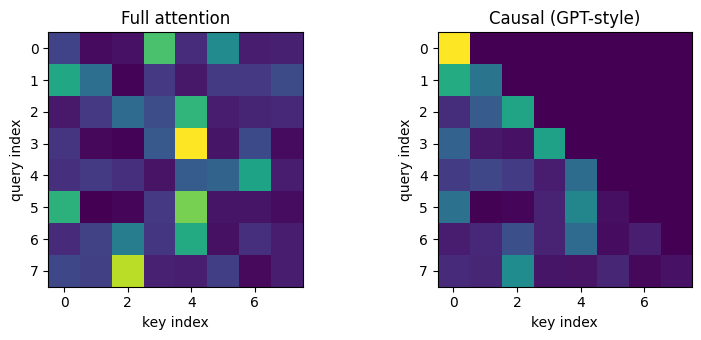

In [3]:
# Visualise the attention pattern with and without a causal mask
L = 8
Q = rng.standard_normal((1, L, 16))
K = rng.standard_normal((1, L, 16))
V = rng.standard_normal((1, L, 16))
causal = np.triu(np.ones((L, L)), k=1)[None]  # 1s above diagonal
_, attn_full = scaled_dot_product_attention(Q, K, V)
_, attn_causal = scaled_dot_product_attention(Q, K, V, mask=causal)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(attn_full[0], cmap='viridis'); axes[0].set_title('Full attention')
axes[1].imshow(attn_causal[0], cmap='viridis'); axes[1].set_title('Causal (GPT-style)')
for a in axes: a.set_xlabel('key index'); a.set_ylabel('query index')
fig.tight_layout(); fig.savefig(IMG_DIR / '01_attention_patterns.png', dpi=150); plt.show()


## 3. Multi-head attention from scratch

In [4]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads, seed=0):
        assert d_model % num_heads == 0
        self.d_model, self.num_heads, self.d_k = d_model, num_heads, d_model // num_heads
        rng = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(d_model)
        self.W_q = rng.standard_normal((d_model, d_model)) * scale
        self.W_k = rng.standard_normal((d_model, d_model)) * scale
        self.W_v = rng.standard_normal((d_model, d_model)) * scale
        self.W_o = rng.standard_normal((d_model, d_model)) * scale

    def _split(self, x):
        B, T, _ = x.shape
        return x.reshape(B, T, self.num_heads, self.d_k).transpose(0, 2, 1, 3)

    def forward(self, X, mask=None):
        Q = self._split(X @ self.W_q)
        K = self._split(X @ self.W_k)
        V = self._split(X @ self.W_v)
        scores = Q @ K.swapaxes(-2, -1) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores + mask * -1e9
        attn = softmax(scores, axis=-1)
        ctx = attn @ V
        B, H, T, dk = ctx.shape
        ctx = ctx.transpose(0, 2, 1, 3).reshape(B, T, H * dk)
        return ctx @ self.W_o, attn

mha = MultiHeadAttention(d_model=64, num_heads=8)
X = rng.standard_normal((2, 6, 64))
out, attn = mha.forward(X)
print('Output shape:', out.shape, 'attention shape:', attn.shape)


Output shape: (2, 6, 64) attention shape: (2, 8, 6, 6)


## 4. Sinusoidal positional encoding

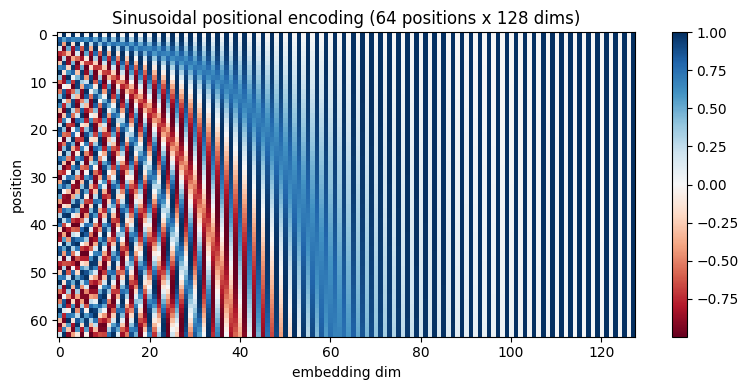

In [5]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])
    return pe

pe = positional_encoding(64, 128)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pe, cmap='RdBu', aspect='auto')
ax.set_xlabel('embedding dim'); ax.set_ylabel('position')
ax.set_title('Sinusoidal positional encoding (64 positions x 128 dims)')
fig.colorbar(im, ax=ax)
fig.tight_layout(); fig.savefig(IMG_DIR / '02_pos_encoding.png', dpi=150); plt.show()


## 5. Complete Transformer encoder block in PyTorch

Pre-LayerNorm variant - the modern default - because it trains stably without warmup.

In [6]:
try:
    import torch
    import torch.nn as nn

    class TransformerEncoderBlock(nn.Module):
        def __init__(self, d_model=128, n_heads=4, d_ff=512, dropout=0.1):
            super().__init__()
            self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
            self.ff = nn.Sequential(
                nn.Linear(d_model, d_ff), nn.GELU(),
                nn.Dropout(dropout), nn.Linear(d_ff, d_model))
            self.ln1 = nn.LayerNorm(d_model)
            self.ln2 = nn.LayerNorm(d_model)
            self.drop = nn.Dropout(dropout)
        def forward(self, x, src_mask=None, src_key_padding_mask=None):
            h = self.ln1(x)
            attn, _ = self.attn(h, h, h, attn_mask=src_mask, key_padding_mask=src_key_padding_mask)
            x = x + self.drop(attn)
            x = x + self.drop(self.ff(self.ln2(x)))
            return x

    block = TransformerEncoderBlock()
    x = torch.randn(2, 10, 128)
    print('Block output:', block(x).shape)
    print('Param count:', sum(p.numel() for p in block.parameters()))
except ModuleNotFoundError:
    print('PyTorch not installed - skipping.')


Block output: torch.Size([2, 10, 128])
Param count: 198272


## 6. A tiny end-to-end Transformer classifier

Trains a 2-layer Transformer encoder on a synthetic 'sum-greater-than-threshold' task so it runs in a few seconds without internet access.

step   0 loss 0.7819 acc 0.496
step  40 loss 0.2262 acc 0.912
step  80 loss 0.1128 acc 0.965
step 120 loss 0.1070 acc 0.953
step 160 loss 0.0935 acc 0.979
step 200 loss 0.0974 acc 0.963
step 240 loss 0.1093 acc 0.965
step 280 loss 0.0893 acc 0.947
step 320 loss 0.0769 acc 0.973
step 360 loss 0.0657 acc 0.971


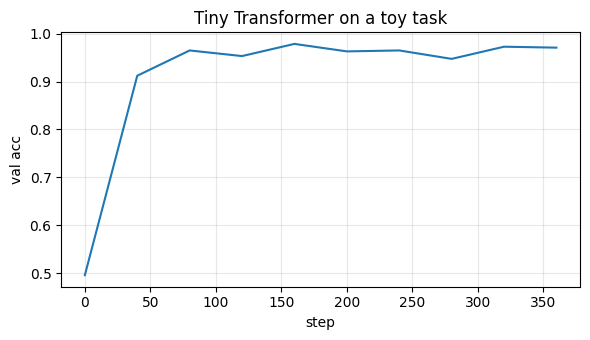

In [7]:
try:
    import torch
    import torch.nn as nn
    set_seed(0)
    VOCAB, SEQ = 30, 16
    def make_batch(batch=256):
        x = torch.randint(0, VOCAB, (batch, SEQ))
        y = (x.sum(dim=1) > SEQ * VOCAB / 2).long()
        return x, y

    class TinyTransformer(nn.Module):
        def __init__(self):
            super().__init__()
            self.emb = nn.Embedding(VOCAB, 64)
            self.pos = nn.Embedding(SEQ, 64)
            self.blocks = nn.ModuleList([TransformerEncoderBlock(64, 4, 128) for _ in range(2)])
            self.head = nn.Linear(64, 2)
        def forward(self, x):
            pos = torch.arange(x.size(1), device=x.device)
            h = self.emb(x) + self.pos(pos)
            for b in self.blocks: h = b(h)
            return self.head(h.mean(dim=1))

    net = TinyTransformer()
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    accs = []
    for step in range(400):
        x, y = make_batch(); opt.zero_grad()
        out = net(x); loss = loss_fn(out, y); loss.backward(); opt.step()
        if step % 40 == 0:
            with torch.no_grad():
                xv, yv = make_batch(512)
                acc = (net(xv).argmax(1) == yv).float().mean().item()
                accs.append(acc); print(f'step {step:3d} loss {loss.item():.4f} acc {acc:.3f}')
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(np.arange(len(accs)) * 40, accs)
    ax.set_xlabel('step'); ax.set_ylabel('val acc'); ax.set_title('Tiny Transformer on a toy task')
    ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(IMG_DIR / '03_tiny_transformer.png', dpi=150); plt.show()
except ModuleNotFoundError:
    print('PyTorch not installed - skipping.')


## 7. Tokenisation strategies side-by-side

BERT uses WordPiece, GPT uses byte-pair encoding (BPE). The cell below shows what each tokenizer does to the same sentence (requires `transformers` to be installed).

In [8]:
sentence = 'The Transformer architecture revolutionised natural language processing in 2017.'
try:
    from transformers import AutoTokenizer
    for name in ['bert-base-uncased', 'gpt2']:
        tok = AutoTokenizer.from_pretrained(name)
        ids = tok.encode(sentence, add_special_tokens=False)
        tokens = tok.convert_ids_to_tokens(ids)
        print(f'{name:25s} {len(tokens):2d} tokens -> {tokens}')
except (ImportError, OSError) as e:
    print('Tokeniser download not available -', type(e).__name__, e)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

bert-base-uncased         12 tokens -> ['the', 'transform', '##er', 'architecture', 'revolution', '##ised', 'natural', 'language', 'processing', 'in', '2017', '.']


...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

gpt2                      12 tokens -> ['The', 'ĠTrans', 'former', 'Ġarchitecture', 'Ġrevolution', 'ised', 'Ġnatural', 'Ġlanguage', 'Ġprocessing', 'Ġin', 'Ġ2017', '.']


## 8. Text generation - temperature, top-k, top-p

In [9]:
def temperature_sample(logits, T=1.0):
    if T <= 0: return int(np.argmax(logits))
    z = np.exp((logits - logits.max()) / T)
    return int(np.random.choice(len(z), p=z / z.sum()))

def top_k_sample(logits, k=10, T=1.0):
    idx = np.argpartition(-logits, k)[:k]
    sub = logits[idx]
    z = np.exp((sub - sub.max()) / T); z /= z.sum()
    return int(idx[np.random.choice(k, p=z)])

def top_p_sample(logits, p=0.9, T=1.0):
    z = np.exp((logits - logits.max()) / T); z /= z.sum()
    order = np.argsort(-z)
    cum = np.cumsum(z[order])
    cut = np.searchsorted(cum, p) + 1
    keep = order[:cut]
    sub = z[keep] / z[keep].sum()
    return int(keep[np.random.choice(len(keep), p=sub)])

rng = np.random.default_rng(0)
logits = rng.standard_normal(50) * 1.5
for name, fn in [('greedy',    lambda l: int(np.argmax(l))),
                 ('temp 0.7',  lambda l: temperature_sample(l, T=0.7)),
                 ('top-k=5',   lambda l: top_k_sample(l, k=5)),
                 ('top-p=0.9', lambda l: top_p_sample(l, p=0.9))]:
    np.random.seed(0)
    samples = [fn(logits) for _ in range(20)]
    print(f'{name:10s} -> {samples}')


greedy     -> [47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47]
temp 0.7   -> [46, 47, 47, 46, 41, 47, 41, 48, 49, 41, 47, 46, 46, 48, 6, 7, 3, 48, 47, 48]
top-k=5    -> [41, 39, 41, 48, 48, 41, 48, 46, 46, 48, 39, 48, 41, 46, 47, 47, 47, 39, 39, 46]
top-p=0.9  -> [42, 19, 42, 42, 46, 49, 46, 33, 44, 39, 24, 21, 42, 5, 47, 47, 47, 38, 7, 2]


## 9. Exercise solutions

### 9.1 MCQ answer key

| Q | Answer | Why |
|---|--------|-----|
| 1 | (b) Parallelisable, gradient-direct, no recurrence | RNNs are sequential, slow on GPUs, and lose long-range context. |
| 2 | (b) Stabilise softmax gradients | Dot products grow with $d_k$; scaling keeps the softmax inputs bounded. |
| 3 | (b) Multiple attention subspaces in parallel | Each head captures a different relation. |
| 4 | (c) Attention itself is permutation-invariant | Positional encoding injects order. |
| 5 | (b) Masked Language Modelling | Random masking forces bidirectional context. |
| 6 | (b) A summary representation for the whole sequence | Used as classifier input. |
| 7 | (b) Allows attention only to previous tokens | Decoder-only auto-regressive. |
| 8 | (b) Aligning sub-word tokens to original word labels | Sub-word tokenisation splits entities. |
| 9 | (d) Top-p sampling | Sets dynamically based on cumulative probability. |
| 10 | (c) Sharper distribution / less diversity | T<1 makes the softmax peakier. |
| 11 | (b) WordPiece | BERT's tokenisation algorithm. |
| 12 | (c) Free-form text generation | Decoder-only is auto-regressive. |


### 9.2 Why RNNs were replaced
Three concrete reasons exposed in the section 2 visualisations:
1. **Sequential compute**: each step depends on the previous step's hidden state, so the GPU sits idle for most of training. The Transformer's attention matrix is one big GEMM that fully utilises modern accelerators.
2. **Gradient decay**: BPTT vanishing gradients limit effective memory to a few dozen tokens. Attention has $O(1)$ gradient path length between any two positions.
3. **Context compression**: every RNN hidden state is a fixed-size summary of the past. Attention can re-look at any past token directly.

### 9.3 Why the $\sqrt{d_k}$ scaling
If $q, k \in \mathbb{R}^{d_k}$ have iid components with mean 0 and variance 1, $q \cdot k$ has variance $d_k$. Large pre-softmax scores push softmax into saturation regions where almost all probability mass collapses onto one position, and the gradient of softmax vanishes everywhere else. Dividing by $\sqrt{d_k}$ keeps the variance of $q \cdot k$ at $1$ regardless of $d_k$, which keeps the softmax in its useful range.

### 9.4 What multi-head attention buys you
Each head operates on a subspace of $d_k = d_{\text{model}} / h$ dimensions. Empirically the heads specialise: one head ends up tracking syntactic dependencies (verb-subject), another tracks coreference, another tracks position-relative patterns. A single head with the same number of parameters would have to learn one weighted average that compromises between all of these patterns.

### 9.5 Why positional encoding is necessary
Self-attention is set-of-vectors $\rightarrow$ set-of-vectors: permuting the input permutes the output identically. To recover order information the input embeddings are augmented with positional encodings (either fixed sinusoids or learned vectors) before the first attention layer.

### 9.6 BERT [CLS] token
BERT prepends a special `[CLS]` token to every input. Its final hidden state is trained, during pre-training, to summarise the whole sequence (next-sentence prediction). At fine-tuning time it is the natural input to a classification head: `Linear(d_model, num_classes)`.

### 9.7 GPT causal mask vs BERT bidirectional
BERT lets every position attend to every other position (bidirectional). GPT applies an upper-triangular mask that prevents a position from attending to future positions - this is what makes GPT a left-to-right language model and lets it be used autoregressively at inference.

### 9.8 NER fine-tuning challenge
The tokenizer may split a single word like *Anthropic* into *An*, *##throp*, *##ic*. Named-entity labels are at the word level; the standard fix is to label only the first subword token and use `-100` (ignored by the loss) for the rest, then aggregate at post-processing time.

### 9.9 Sampling strategies
Already implemented in section 8. **Top-p** (nucleus sampling) is the modern default: it adapts the candidate-set size based on how confident the distribution is. If only two tokens cover 90 % of probability mass, you sample from a tiny set; if many tokens share probability, you sample from a wider set. Top-k cannot adapt this way.

### 9.10 Temperature $T<1$
Dividing logits by $T<1$ multiplies their magnitude, which after softmax pushes more mass onto the most likely token. The distribution becomes sharper and generation more deterministic. $T \to 0$ recovers greedy decoding.

### 9.11 Tokenisation algorithms
BERT: WordPiece. GPT: BPE. Modern open-source models often use SentencePiece (a wrapper that can produce BPE or unigram outputs from raw bytes). The choice affects vocabulary size, handling of unknown characters, and how multilingual tokens are represented.

### 9.12 Encoder-only vs decoder-only
- **Encoder-only (BERT)**: best for classification, NER, extractive QA - tasks where the model consumes the whole input and produces a single label or set of spans.
- **Decoder-only (GPT)**: best for free-form text generation, summarisation, instruction following.
- **Encoder-decoder (T5, BART)**: best for sequence-to-sequence tasks like translation.

---
*End of Chapter 6.*
